# Projekt Zespołowy 2 — Zespół 10, "Sieci"

In [75]:
try:
	from google.colab import drive
	drive.mount('/content/drive')
	AMPL_Path = "drive/MyDrive"
except:
	AMPL_Path = ".."

# Benchmark AMPL

In [76]:
%pip install amplpy networkx pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


Licensed to AMPL Community Edition License for <filipf47255@gmail.com>.
CPLEX 22.1.2CPLEX 22.1.2: optimal solution; objective 6050
29 simplex iterations
Total cost: 6050.0
Flow matrix:
                             usage.val
index0 index1 index2 index3           
1      2      1      2              30
                     3               0
                     4               0
                     5               0
              2      3               0
...                                ...
5      4      2      4              25
                     5               0
              3      4              16
                     5               0
              4      5               0

[200 rows x 1 columns]
Encrypted edges:
               encrypted.val
index0 index1               
1      2                   1
       3                   0
       4                   0
       5                   1
2      3                   0
       4                   1
       5                   0
3     

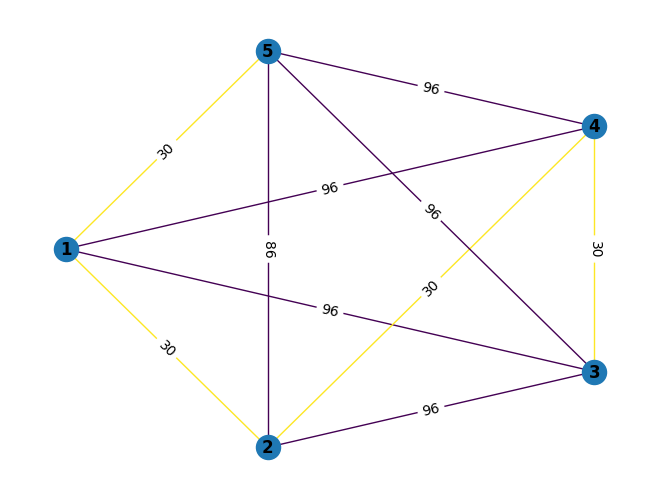

In [77]:
from pathlib import PurePath
from amplpy import ampl_notebook
import networkx as nx
import matplotlib.pyplot as plt


ampl = ampl_notebook(
    modules=["cplex"],
    license_uuid="2ac42500-338f-4917-9b9e-8fdc1cc63912"
)
ampl.read(str(PurePath(f"{AMPL_Path}/AMPL/PZSP2.mod")))
ampl.read_data(str(PurePath(f"{AMPL_Path}/AMPL/PZSP2.dat")))
N = ampl.get_parameter("n").value()
ampl.option["solver"] = "cplex"
ampl.solve()
assert ampl.solve_result == "solved"

print(f"Total cost: {ampl.get_objective("total_cost").value()}")
flow = ampl.get_variable("usage").get_values().to_pandas()
print(f"Flow matrix:\n{flow}")
encryption = ampl.get_variable("encrypted").get_values().to_pandas()
print(f"Encrypted edges:\n{encryption}")
bandwidth = ampl.get_data("{(i,j) in EDGES} sum {(k,l) in CONNECTIONS} (usage[i,j,k,l]+usage[j,i,k,l])").to_pandas()
bandwidth.rename(columns={bandwidth.columns[0]: "bandwidth"}, inplace=True)
print(f"Bandwidth usage:\n{bandwidth}")

G = nx.Graph()
G.add_nodes_from(range(1,N+1))
G.add_weighted_edges_from([(i,j,bandwidth.at[(i,j),"bandwidth"]) for i in range(1,N+1) for j in range(1,N+1) if i<j])
nx.set_edge_attributes(G, encryption.to_dict()['encrypted.val'], "encrypted")
print(list(G.edges))
print(nx.get_edge_attributes(G, "encrypted"))
colors = [edge[2] for edge in G.edges.data("encrypted")]
pos = nx.shell_layout(G)
nx.draw(G, pos=pos, with_labels=True, font_weight='bold', edge_color=colors)
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=nx.get_edge_attributes(G, "weight"))
plt.show()

# Algorytm Ewolucyjny (WIP)

In [78]:
%pip install torch numpy pydantic scikit-learn jaxtyping beartype

Note: you may need to restart the kernel to use updated packages.


In [79]:
import torch
from torch import Tensor
from torch.distributions import Distribution, Bernoulli, Categorical
from pydantic import BaseModel, Field, computed_field, ConfigDict, PrivateAttr
from typing import NamedTuple, Optional, Callable, no_type_check
from beartype import beartype
from jaxtyping import Float, Bool, jaxtyped # type: ignore
from abc import ABC, abstractmethod
import functools
import pprint
import time
import matplotlib.pyplot as plt
import numpy as np
pp = pprint.PrettyPrinter(indent=4)

## CUDA

In [80]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Running on {device} ---")
torch.set_default_device(device)

--- Running on cuda ---


## Helpers

In [81]:
def multi_triu(
    tensor: torch.Tensor,
    dim_pairs: list[tuple[int, int]],
    value: float = 0.0
) -> torch.Tensor:
    """
    Multiple triu between dim pairs
    """
    if not dim_pairs:
        return tensor.clone()
        
    shape = tensor.shape
    ndim = tensor.ndim

    all_masks: list[Tensor] = []
    for dim_a, dim_b in dim_pairs:
        if not (0 <= dim_a < ndim and 0 <= dim_b < ndim):
            raise IndexError(f"Dimension index out of range. Tensor has {ndim} dims, got pair ({dim_a}, {dim_b})")

        size_a = shape[dim_a]
        size_b = shape[dim_b]
        
        view_shape_a = [1] * ndim
        view_shape_a[dim_a] = size_a
        indices_a = torch.arange(size_a).view(view_shape_a)
        
        view_shape_b = [1] * ndim
        view_shape_b[dim_b] = size_b
        indices_b = torch.arange(size_b).view(view_shape_b)

        pair_mask = (indices_a >= indices_b)
        all_masks.append(pair_mask)
        
    final_mask = functools.reduce(torch.logical_and, all_masks)
    
    tensor[final_mask.expand_as(tensor)] = value
    return tensor

## Representation
`P` - population size

`N` - number of nodes

`T` - number of transponder types

`C` - number of constraints

In [82]:
# ruff: noqa: F722
# ruff: noqa: F821
# Above from: https://docs.kidger.site/jaxtyping/faq/

class Population(NamedTuple):
    encrypted_neigh_matrix: Bool[Tensor, "N N"]
    path_edge_bandwidth_usage: Float[Tensor, "P N N N N"]
    path_transponder_assignment: Float[Tensor, "P N N T"]
    regular_bandwidth: int = 96
    encrypted_bandwidth: int = 30

    @classmethod
    @jaxtyped(typechecker=beartype)
    def masked(cls, 
               encrypted_neigh_matrix: Bool[Tensor, "N N"],
               path_edge_bandwidth_usage: Float[Tensor, "P N N N N"],
               path_transponder_assignment: Float[Tensor, "P N N T"]
               ):
        idx = torch.arange(0, path_edge_bandwidth_usage.size(1))
        path_edge_bandwidth_usage[:, :, :, idx, idx] = 0.0
        new_transponders_masked = multi_triu(path_transponder_assignment, dim_pairs=[(1,2)]) # (P, *N, *N, T)
        return cls(encrypted_neigh_matrix, path_edge_bandwidth_usage, new_transponders_masked)
    
    @computed_field
    @property
    @jaxtyped(typechecker=beartype)
    def edge_size_limits(self) -> Float[Tensor, "N N"]:
        return (self.encrypted_neigh_matrix.float() * self.encrypted_bandwidth + (~self.encrypted_neigh_matrix).float() * self.regular_bandwidth)


## Visualizations

In [83]:
@no_type_check
def visualize_population_individual(
    population: Population, 
    transponder_capacities: Float[Tensor, "T"],
    individual_index: int = 0, 
    title_suffix: str = ""
):
    if individual_index >= len(population.path_edge_bandwidth_usage):
        print(f"Error: individual_index {individual_index} out of range.")
        return

    e_matrix = population.encrypted_neigh_matrix
    p_usage = population.path_edge_bandwidth_usage[individual_index]
    t_assign = population.path_transponder_assignment[individual_index]

    edge_bw_usage = torch.einsum("ijkl -> kl", p_usage) 
    edge_bw_usage += edge_bw_usage.tril(diagonal=-1).mT
    edge_bw_usage.triu_(diagonal=1)
    
    path_capacity = t_assign @ transponder_capacities

    total_trans_usage = t_assign.sum(dim=(0, 1))

    data_to_plot = [e_matrix, edge_bw_usage, path_capacity, total_trans_usage, transponder_capacities]
    e_np, edge_np, path_np, trans_np, caps_np = [
        (d.cpu().detach().numpy() if d.is_cuda else d.detach().numpy()) 
        for d in data_to_plot
    ]
    
    N = e_np.shape[0]
    T = caps_np.shape[0]
    node_labels = [f'Node {i}' for i in range(N)]
    trans_labels = [f'Type {i}' for i in range(T)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    title = f"Visualization for Individual {individual_index}"
    if title_suffix:
        title = f"{title} ({title_suffix})"
    fig.suptitle(title, fontsize=16)

    ax = axes[0, 0]
    ax.imshow(e_np, cmap='Greys', interpolation='nearest')
    ax.set_title('Encrypted Adjacency Matrix (1 = Encrypted)')
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    ax.set_xticklabels(node_labels)
    ax.set_yticklabels(node_labels)
    
    for i in range(N):
        for j in range(N):
            text_val = int(e_np[i, j])
            color = 'white' if text_val == 1 else 'black'
            ax.text(j, i, text_val, ha='center', va='center', color=color)
    
    ax = axes[0, 1]
    cax2 = ax.imshow(edge_np, cmap='viridis', interpolation='nearest', vmin=0)
    ax.set_title('Total Edge Bandwidth Usage (on physical edges)')
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    ax.set_xticklabels(node_labels)
    ax.set_yticklabels(node_labels)
    fig.colorbar(cax2, ax=ax, orientation='vertical', label='Total Bandwidth Used')

    ax = axes[1, 0]
    cax3 = ax.imshow(path_np, cmap='plasma', interpolation='nearest', vmin=0)
    ax.set_title('Effective Path Capacity (per path i->j)')
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    ax.set_xticklabels(node_labels)
    ax.set_yticklabels(node_labels)
    fig.colorbar(cax3, ax=ax, orientation='vertical', label='Effective Capacity')

    ax = axes[1, 1]
    bars4 = ax.bar(trans_labels, trans_np, color='coral')
    ax.set_title('Total Transponder Bandwidth Assigned')
    ax.set_ylabel('Total Bandwidth')
    ax.set_xlabel('Transponder Type')
    ax.bar_label(bars4, fmt='%.1f')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

@no_type_check
def visualize_input_data(neigh_matrix: Bool[Tensor, "N N"], demand: Float[Tensor, "N N"], transponder_costs: Float[Tensor, "T"], transponder_capacities: Float[Tensor, "T"]):
    if neigh_matrix.is_cuda:
        neigh_matrix = neigh_matrix.cpu()
    if demand.is_cuda:
        demand = demand.cpu()
    if transponder_costs.is_cuda:
        transponder_costs = transponder_costs.cpu()
    if transponder_capacities.is_cuda:
        transponder_capacities = transponder_capacities.cpu()

    mat_np = neigh_matrix.numpy() 
    dem_np = demand.numpy()
    costs_np = transponder_costs.numpy() 
    caps_np = transponder_capacities.numpy()
    
    N = mat_np.shape[0]
    T = costs_np.shape[0]
    node_labels = [f'Node {i}' for i in range(N)]
    trans_labels = [f'Type {i}' for i in range(T)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('EA Input Data Visualization', fontsize=16)

    ax = axes[0, 0]
    ax.imshow(mat_np, cmap='Greys', interpolation='nearest')
    ax.set_title('Neighborhood Matrix (1 = Edge Exists)')
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    ax.set_xticklabels(node_labels)
    ax.set_yticklabels(node_labels)
    
    for i in range(N):
        for j in range(N):
            text_val = int(mat_np[i, j])
            color = 'white' if text_val == 1 else 'black'
            ax.text(j, i, text_val, ha='center', va='center', color=color)
    
    ax = axes[0, 1]
    cax2 = ax.imshow(dem_np, cmap='viridis', interpolation='nearest', vmin=0)
    ax.set_title('Demand Matrix (Bandwidth)')
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    ax.set_xticklabels(node_labels)
    ax.set_yticklabels(node_labels)
    
    for i in range(N):
        for j in range(N):
            val = dem_np[i, j]
            if val > 0:
                color = 'black' if cax2.norm(val) > 0.7 else 'white'
                ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color)
    fig.colorbar(cax2, ax=ax, orientation='vertical', label='Bandwidth Demand')

    ax = axes[1, 0]
    bars3 = ax.bar(trans_labels, costs_np, color='skyblue')
    ax.set_title('Transponder Costs')
    ax.set_ylabel('Cost ($)')
    ax.set_xlabel('Transponder Type')
    ax.bar_label(bars3, fmt='$%.0f')

    ax = axes[1, 1]
    bars4 = ax.bar(trans_labels, caps_np, color='lightgreen')
    ax.set_title('Transponder Capacities')
    ax.set_ylabel('Capacity (Gbps)')
    ax.set_xlabel('Transponder Type')
    ax.bar_label(bars4, fmt='%.0f')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

`P` - population size
`N` - number of nodes
`T` - number of transponder types
`C` - number of constraints

## Constraints

In [84]:
class Constraint(ABC, BaseModel):
    weight: float = 1.0
    readable_name: str
    @abstractmethod
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        """Calculate compliance score for each individual [0,1]"""
        ...
    @abstractmethod
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        """Calculate compliance score for each element [0,1]"""
        ...
    @jaxtyped(typechecker=beartype)
    def _mean_similarity_scores(self, scores: Float[Tensor, "P ..."]) -> Float[Tensor, "P"]:
        return torch.mean(scores.flatten(start_dim=1), dim=1)

    @jaxtyped(typechecker=beartype)
    def _calculate_similarity_scores_all(self, a: Float[Tensor, "P ..."], b: Float[Tensor, "P ..."], diff_transform: Callable[[Tensor], Tensor]= torch.abs) -> Float[Tensor, "P ..."]:
        diff = diff_transform(a - b) 
        goal = torch.max(a, b)
        ratio = diff / goal
        # this one has no mean for DependentDemand
        return ratio.nan_to_num_()
    
    @jaxtyped(typechecker=beartype)
    def _calculate_similarity_scores_from_sums(self, a: Float[Tensor, "P ..."], b: Float[Tensor, "P ..."], diff_transform: Callable[[Tensor], Tensor]= torch.abs) -> Float[Tensor, "P"]:
        # this one is useful for hard constraints that use relu (demand, bandwidth limit)
        diff = diff_transform(a - b) 
        goal = torch.max(a, b)
        per_population_diff = diff.flatten(start_dim=1).sum(dim=1)
        per_population_goal = goal.flatten(start_dim=1).sum(dim=1)
        ratio = per_population_diff / per_population_goal
        # For zero division
        return ratio.nan_to_num_()

class PathBandwidthIOMatch(Constraint):
    readable_name: str = "Path Bandwidth IO Match"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        return self._mean_similarity_scores(self._check_all(population, transponder_capacities, demand))

    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P N N"]:
        p = population.path_edge_bandwidth_usage
        source_output_sum = torch.einsum('pijil -> pij', p) # (P, N, N, N, N) -> (P, N, N)
        dest_input_sum = torch.einsum('pijkj -> pij', p) # (P, N, N, N, N) -> (P, N, N)
        return self._calculate_similarity_scores_all(source_output_sum, dest_input_sum)
    
class PathTransponderBandwidthMatch(Constraint):
    readable_name: str = "Path Transponder Bandwidth Match"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        return self._mean_similarity_scores(self._check_all(population, transponder_capacities, demand))

    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P N N"]:
        p = population.path_edge_bandwidth_usage
        t = population.path_transponder_assignment
        # just check for source because PathBandwidthIOMatch ensures IO equality
        source_output_sum = torch.einsum('pijil -> pij', p) # (P, N, N, N, N) -> (P, N, N)
        transponder_on_path_count = t.sum(dim=3) # (P, N, N, T) -> (P, N, N)
        return self._calculate_similarity_scores_all(source_output_sum, transponder_on_path_count)

class PathTransponderBandwidthAtLeast(Constraint):
    readable_name: str = "At Least As Many Paths As Transponders"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        return self._mean_similarity_scores(self._check_all(population, transponder_capacities, demand))

    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P N N"]:
        p = population.path_edge_bandwidth_usage
        t = population.path_transponder_assignment
        # just check for source because PathBandwidthIOMatch ensures IO equality
        source_output_sum = torch.einsum('pijil -> pij', p) # (P, N, N, N, N) -> (P, N, N)
        transponder_on_path_count = t.sum(dim=3) # (P, N, N, T) -> (P, N, N)
        # same as above, just with relu for paths >= transponders -> 0
        return self._calculate_similarity_scores_all(transponder_on_path_count, source_output_sum, diff_transform=torch.relu)
    
class PathEdgeBandwidthKirchhoff(Constraint):
    readable_name: str = "Path Edge Bandwidth Kirchhoff"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        return self._mean_similarity_scores(self._check_all(population, transponder_capacities, demand))

    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P N N N"]:
        p = population.path_edge_bandwidth_usage
        N = population.encrypted_neigh_matrix.size(1)
        node_input_sum = torch.einsum('pijax -> pijx', p) # (P, N, N, N, N) -> (P, N, N, N) for each node on each path
        node_output_sum = torch.einsum('pijxb -> pijx', p) # (P, N, N, N, N) -> (P, N, N, N) for each node on each path
        # check that for each node on each path input and output matches
        # path root and dest (i, j) should be excluded
        identity_maks = torch.eye(N, dtype=torch.bool)
        mask_x_eq_i = identity_maks.view(1, N, 1, N)
        mask_x_eq_j = identity_maks.view(1, 1, N, N)
        final_mask = (mask_x_eq_i | mask_x_eq_j)
        node_input_sum[final_mask.expand_as(node_input_sum)] = 0.0
        node_output_sum[final_mask.expand_as(node_output_sum)] = 0.0
        return self._calculate_similarity_scores_all(node_input_sum,node_output_sum)
    
class Demand(Constraint):
    readable_name: str = "Demand"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        demand_per_individual, path_coverage = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the coverage >= demand -> score = 0
        return self._calculate_similarity_scores_from_sums(demand_per_individual, path_coverage, diff_transform=torch.relu)    

    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P ..."]:
        demand_per_individual, path_coverage = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the coverage >= demand -> score = 0
        return self._calculate_similarity_scores_all(demand_per_individual, path_coverage, diff_transform=torch.relu)

    def _calc(self, population, transponder_capacities, demand):
        t = population.path_transponder_assignment #(P, N, N, T)
        P = t.size(0)
        path_coverage = t @ transponder_capacities # (P, N, N, T) @ (T,) -> (P, N, N)
        demand_per_individual = demand.unsqueeze(0).expand(P, -1, -1)
        return demand_per_individual, path_coverage

class DependentDemand(Constraint):
    readable_name: str = "Dependent Demand"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        demand_per_individual, path_coverage = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the coverage >= demand -> score = 0
        return self._calculate_similarity_scores_from_sums(demand_per_individual, path_coverage, diff_transform=torch.relu)
    
    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P ..."]:
        demand_per_individual, path_coverage = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the coverage >= demand -> score = 0
        return self._calculate_similarity_scores_all(demand_per_individual, path_coverage, diff_transform=torch.relu)
    
    def _calc(self, population, transponder_capacities, demand):
        t = population.path_transponder_assignment #(P, N, N, T)
        P = t.size(0)
        path_coverage = t @ transponder_capacities # (P, N, N, T) @ (T,) -> (P, N, N)
        # actual demand coverage is dependent on the amount of complete paths:
        real_paths = PathBandwidthIOMatch()._check_all(population, transponder_capacities, demand)\
					* PathTransponderBandwidthAtLeast()._check_all(population, transponder_capacities, demand)\
					* PathEdgeBandwidthKirchhoff()._check_all(population, transponder_capacities, demand).flatten(start_dim=3).mean(dim=3)
        path_coverage *= real_paths
        demand_per_individual = demand.unsqueeze(0).expand(P, -1, -1)
        return demand_per_individual, path_coverage

class BandwidthLimit(Constraint):
    readable_name: str = "Bandwidth Limit"
    @jaxtyped(typechecker=beartype)
    def check(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P"]:
        edge_size_useage, pop_edge_size_limits = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the limit >= useage -> score = 0
        return self._calculate_similarity_scores_from_sums(edge_size_useage, pop_edge_size_limits, diff_transform=torch.relu)
    
    @jaxtyped(typechecker=beartype)
    def _check_all(self, population: Population, transponder_capacities: Float[Tensor, "T"], demand: Float[Tensor, "N N"]) -> Float[Tensor, "P ..."]:
        edge_size_useage, pop_edge_size_limits = self._calc(population, transponder_capacities, demand)
        #relu to cut negative scores. If the limit >= useage -> score = 0
        return self._calculate_similarity_scores_all(edge_size_useage, pop_edge_size_limits, diff_transform=torch.relu)

    def _calc(self, population, transponder_capacities, demand):
        e = population.edge_size_limits #(N, N)
        p = population.path_edge_bandwidth_usage #(P, N, N, N, N)
        pop_edge_size_limits = e.unsqueeze(0).expand(p.size(0), e.size(0), e.size(1)) #(P, N, N)
        edge_size_useage = torch.einsum("pijkl -> pkl", p) #(P, N, N)
        edge_size_useage += edge_size_useage.tril(diagonal=-1).mT
        return edge_size_useage.triu_(diagonal=1), pop_edge_size_limits

## Selections

In [85]:
class Selection(ABC):
    @abstractmethod
    def get_next_generation(self, population: Population, penalties: Float[Tensor, "P"], elite_size: int) -> Population:
        ...

class TournamentSelection(Selection, BaseModel):
    k: int
    def get_next_generation(self, population: Population, penalties: Float[Tensor, "P"], elite_size: int) -> Population:
        elite_paths = population.path_edge_bandwidth_usage[:elite_size]
        elite_transponders = population.path_transponder_assignment[:elite_size]

        population_size = penalties.size(0)
        tournaments_idx = torch.randint(
            low=0, 
            high=population_size, 
            size=(population_size-elite_size, self.k),
        ) # (P-elite_size, k)
        
        tournament_penalties = penalties[tournaments_idx] # (P-elite_size, k)
        winner_local_indices = torch.min(tournament_penalties, dim=1).indices # (P-elite_size)
        row_indices = torch.arange(population_size-elite_size)
        final_winner_indices = tournaments_idx[row_indices, winner_local_indices] 

        selected_paths = population.path_edge_bandwidth_usage[final_winner_indices]
        selected_transponders = population.path_transponder_assignment[final_winner_indices]

        new_paths = torch.cat((elite_paths, selected_paths), dim=0)
        new_transponders = torch.cat((elite_transponders, selected_transponders), dim=0)

        return Population(
            encrypted_neigh_matrix=population.encrypted_neigh_matrix,
            path_edge_bandwidth_usage=new_paths,
            path_transponder_assignment=new_transponders
        )

## Mutations

In [86]:
class Mutation(ABC):
    @abstractmethod
    def mutate(self, population : Population, elite_size: int) -> Population:
        ...

class GeneMutation(Mutation, BaseModel):
    """
    Applies element-wise "gene" mutation to non-elite individuals.

    For each element (gene) in each tensor, a Bernoulli trial determines
    whether it should be mutated, based on component-specific probabilities.

    The mutation logic is as follows:
    - Paths (float):   New = (1 - X_P) * Old + X_P * Random_P
    - Transp. (float): New = (1 - X_T) * Old + X_T * Random_T

    Where:
    - X is a mutation mask (0 or 1) from Bernoulli(p_mut).
    - Random is a new value sampled from a given distribution.
    - neigh_matrix is a global mask to ensure graph validity.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)
    path_edge_bandwidth_usage_mut_proba: float
    path_transponder_assignment_mut_proba: float

    def mutate(self, population : Population, elite_size: int) -> Population:
        elite_paths = population.path_edge_bandwidth_usage[:elite_size]
        elite_transponders = population.path_transponder_assignment[:elite_size]

        non_elite_paths = population.path_edge_bandwidth_usage[elite_size:]
        non_elite_transponders = population.path_transponder_assignment[elite_size:]

        paths_mut_idx = Bernoulli(self.path_edge_bandwidth_usage_mut_proba)\
            .sample(non_elite_paths.size())
        transponders_mut_idx = Bernoulli(self.path_transponder_assignment_mut_proba)\
            .sample(non_elite_transponders.size())
        
        #TODO: Masking with idx to not calculate random for 0 indices
        random_paths = torch.poisson(non_elite_paths).clamp(max=population.edge_size_limits)
        random_transponders = torch.poisson(non_elite_transponders)
   
        mutated_paths = (1 -  paths_mut_idx) * non_elite_paths +\
                                        paths_mut_idx * random_paths
        mutated_transponders = (1 -  transponders_mut_idx) * non_elite_transponders +\
                                        transponders_mut_idx * random_transponders
        
        new_paths = torch.cat((elite_paths, mutated_paths), dim=0)
        new_transponders = torch.cat((elite_transponders, mutated_transponders), dim=0)
        
        
        return Population.masked(
            encrypted_neigh_matrix=population.encrypted_neigh_matrix,
            path_edge_bandwidth_usage=new_paths,
            path_transponder_assignment=new_transponders
        )
class UniformCrossover(Mutation, BaseModel):
    """
    Applies element-wise uniform crossover based on the logic:
    - Child1 = X * Parent1 + (1 - X) * Parent2
    - Child2 = X * Parent2 + (1 - X) * Parent1
    
    Where X is a tensor of Bernoulli samples (0 or 1).
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    path_edge_bandwidth_usage_cross_proba: float
    path_transponder_assignment_cross_proba: float

    @jaxtyped(typechecker=beartype)
    def _cross_component(self, 
                         parent1: Tensor, 
                         parent2: Tensor, 
                         proba: float
                         ) -> tuple[Tensor, Tensor]:
        """
        Performs uniform crossover on a single component (E, P, or T)
        for a batch of parent pairs.
        """
        cross_mask = Bernoulli(proba).sample(parent1.size())

        if parent1.dtype == torch.bool:
            # Boolean logic: Child1 = (X & P1) | (~X & P2)
            cross_mask = cross_mask.bool()
            child1 = (cross_mask & parent1) | (~cross_mask & parent2)
            child2 = (cross_mask & parent2) | (~cross_mask & parent1)
        else:
            # Float logic: Child1 = X * P1 + (1 - X) * P2
            cross_mask = cross_mask.float()
            child1 = cross_mask * parent1 + (1.0 - cross_mask) * parent2
            child2 = cross_mask * parent2 + (1.0 - cross_mask) * parent1
            
        return child1, child2

    @jaxtyped(typechecker=beartype)
    def mutate(self, population : Population, elite_size: int) -> Population:
        elite_paths = population.path_edge_bandwidth_usage[:elite_size]
        elite_transponders = population.path_transponder_assignment[:elite_size]

        non_elite_paths = population.path_edge_bandwidth_usage[elite_size:]
        non_elite_transponders = population.path_transponder_assignment[elite_size:]

        num_to_cross = non_elite_paths.size(0)

        if num_to_cross < 2:
            return population

        indices = torch.randperm(num_to_cross)
        shuffled_paths = non_elite_paths[indices]
        shuffled_transponders = non_elite_transponders[indices]

        num_pairs = num_to_cross // 2
        
        # first parent
        p1_paths = shuffled_paths[:num_pairs]
        p1_trans = shuffled_transponders[:num_pairs]
        
        # second parent
        p2_paths = shuffled_paths[num_pairs : 2 * num_pairs]
        p2_trans = shuffled_transponders[num_pairs : 2 * num_pairs]

        # remainder
        rem_paths = shuffled_paths[2 * num_pairs:]
        rem_trans = shuffled_transponders[2 * num_pairs:]
        
        c1_paths, c2_paths = self._cross_component(
            p1_paths, p2_paths, self.path_edge_bandwidth_usage_cross_proba
        )
        c1_trans, c2_trans = self._cross_component(
            p1_trans, p2_trans, self.path_transponder_assignment_cross_proba
        )

        crossed_paths = torch.cat((c1_paths, c2_paths, rem_paths), dim=0)
        crossed_trans = torch.cat((c1_trans, c2_trans, rem_trans), dim=0)

        # add elites back
        new_paths = torch.cat((elite_paths, crossed_paths), dim=0)
        new_transponders = torch.cat((elite_transponders, crossed_trans), dim=0)

        return Population.masked(
            encrypted_neigh_matrix=population.encrypted_neigh_matrix,
            path_edge_bandwidth_usage=new_paths,
            path_transponder_assignment=new_transponders
        )

## Terminal Conditions

In [87]:
class TerminationCondition(ABC):
    @abstractmethod
    def check(self, lowest_penalty: float, iteration_n: int) -> bool:
        """False on termination"""
        ...

class MaxIterations(TerminationCondition, BaseModel):
    iterations: int
    
    _total_iteration_time: float = PrivateAttr(default=0.0)
    _last_start_time: float = PrivateAttr(default=0.0)

    def check(self, lowest_penalty: float, iteration_n: int) -> bool:
        if not iteration_n:
            self._last_start_time = time.perf_counter()
            return iteration_n < self.iterations
        current_time = time.perf_counter()
        
        #Calculates the duration since the end of pvevious check to the beggining of current
        iteration_duration = current_time - self._last_start_time
        self._total_iteration_time += iteration_duration
            
        avg_iteration_time = self._total_iteration_time / iteration_n

        print("-" * 40)
        print(f"it: {iteration_n}/{self.iterations}")
        print(f"avg_iter_time: {avg_iteration_time:.4f}s")
            
        remaining_iters = self.iterations - iteration_n
        remaining_time_sec = remaining_iters * avg_iteration_time

        if remaining_time_sec < 0:
            print("projected_rem: --")
        elif remaining_time_sec < 60:
            print(f"projected_rem: {remaining_time_sec:.1f}s")
        elif remaining_time_sec < 3600:
            print(f"projected_rem: {remaining_time_sec / 60:.1f} min")
        else:
            print(f"projected_rem: {remaining_time_sec / 3600:.2f} hr")

        self._last_start_time = current_time

        return iteration_n < self.iterations
    
class MinImprovement(TerminationCondition, BaseModel):
    #TODO: Patience
    delta: float
    _prev_score: Optional[float] = PrivateAttr(default=None) 
    def check(self, lowest_penalty: float, iteration_n: int) -> bool:
        if not self._prev_score:
            self._prev_score = lowest_penalty
            return True
        diff = abs(lowest_penalty - self._prev_score)
        self._prev_score = lowest_penalty
     
        return diff > self.delta

## Algorithm

In [88]:
class EA(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)
    
    population_size: int
    elite_size: int

    path_edge_bandwidth_usage_init_distribution: Distribution
    path_transponder_assignment_init_distribution: Distribution
    
    global_constraint_weight: float = 10.0**5
    constraints: list[Constraint] = Field(default_factory=lambda _: [])

    termination_conditions: list[TerminationCondition] = Field(default_factory=lambda _: [])
    selection_method: Selection
    mutation_methods: list[Mutation] = Field(default_factory=lambda _: [])

    show_vizualisation_every_n_iter: int = 10000
    

    @computed_field
    @property
    @jaxtyped(typechecker=beartype)
    def constraint_weights_tensor(self) -> Float[Tensor, "C"]:
        constraint_weights = [c.weight for c in self.constraints]
        return torch.tensor(constraint_weights, dtype=torch.float32)
    
    def _get_encrypted_MST(self, neigh_matrix: Bool[Tensor, "N N"]) -> Bool[Tensor, "N N"]:
        G = nx.from_numpy_array(neigh_matrix.cpu().numpy())
        betweenness = nx.edge_betweenness_centrality(G, normalized=False)
        nx.set_edge_attributes(G, betweenness, "betweenness")
        return torch.triu(torch.from_numpy(nx.to_numpy_array(nx.minimum_spanning_tree(G, "betweenness"), dtype=bool)).to(device), diagonal=1)


    def _sample_init_population(self, N: int, T: int, neigh_matrix: Bool[Tensor, "N N"]) -> Population:
        # TODO: Move to module
        encrypted_neigh_matrix = self._get_encrypted_MST(neigh_matrix)
        
        path_edge_bandwidth_usage_size = torch.Size([self.population_size, N, N, N, N])
        path_edge_bandwidth_usage = self.path_edge_bandwidth_usage_init_distribution\
            .sample(path_edge_bandwidth_usage_size).float() # (P, N, N, N, N)
        path_transponder_assignment_size = torch.Size([self.population_size, N, N, T])
        path_transponder_assignment = self.path_transponder_assignment_init_distribution\
            .sample(path_transponder_assignment_size).float() # (P, N, N, T)
        return Population.masked(
            encrypted_neigh_matrix=encrypted_neigh_matrix,
            path_edge_bandwidth_usage=path_edge_bandwidth_usage,
            path_transponder_assignment=path_transponder_assignment
        )
    
    
    @jaxtyped(typechecker=beartype)
    def _check_constraints(self, 
                           population: Population,
                           transponder_capacities: Float[Tensor, "T"],
                           demand: Float[Tensor, "N N"]
                           ) -> Float[Tensor, "C P"]:
        if not self.constraints:
            P = population.path_edge_bandwidth_usage.size(0)
            return torch.empty(0, P)
        all_scores = [c.check(population, transponder_capacities, demand) for c in self.constraints]
        
        return torch.stack(all_scores, dim=0)
          

    @jaxtyped(typechecker=beartype)
    def _calculate_total_transponder_cost(self, population: Population, transponder_costs: Float[Tensor, "T"]) -> Float[Tensor, "P"]:
        path_costs = population.path_transponder_assignment @ transponder_costs # (P, N, N, T) @ (T) -> (P, N, N)
        return path_costs.sum(dim=(1,2)) # (P, N, N).sum(dim=(1, 2)) -> (P,)
    
    def _count_num_of_encrypted_connections(self, population: Population) -> Float:
        return population.encrypted_neigh_matrix.sum().float() # (N, N).sum(dim=(1, 2)) -> float

    @jaxtyped(typechecker=beartype)
    def _penalty(
            self, 
            constraint_scores: Float[Tensor, "C P"],
            total_transponder_cost: Float[Tensor, "P"]
            ) -> Float[Tensor, "P"]:
        constraint_product = torch.prod(1-constraint_scores, dim=0) # (P)
        return total_transponder_cost / constraint_product + self.global_constraint_weight * (1-constraint_product)
        # w_constraint_total = self.constraint_weights_tensor @ constraint_scores # (P)
        # return total_transponder_cost + w_constraint_total * (total_transponder_cost + self.global_constraint_weight)
    
    @jaxtyped(typechecker=beartype)
    def run(
            self,
            neigh_matrix: Bool[Tensor, "N N"],
            demand: Float[Tensor, "N N"],
            transponder_costs: Float[Tensor, "T"],  
            transponder_capacities: Float[Tensor, "T"]
            ):

        if self.elite_size >= self.population_size:
            raise ValueError("Elite should be smaller than the population!")

        N = neigh_matrix.size(0)
        T = transponder_capacities.size(0)

        population = self._sample_init_population(N, T, neigh_matrix)
        lowest_penalty = float('inf')
        iteration_n = 0
        lowest_penalty_constraint_scores: list[float] = [1.0 for _ in self.constraints]
        lowest_transponder_cost = float('inf')
        visualize_population_individual(population, transponder_capacities, 0)
        while all([cond.check(lowest_penalty, iteration_n) for cond in self.termination_conditions]):
            iteration_n += 1
            if iteration_n % self.show_vizualisation_every_n_iter == 0:
                visualize_population_individual(population, transponder_capacities, 0)
            constraint_scores = self._check_constraints(population, transponder_capacities, demand) # (C, P)
            total_transponder_cost = self._calculate_total_transponder_cost(population, transponder_costs) # (P)
            penalties = self._penalty(
                constraint_scores, 
                total_transponder_cost
                )
            #TODO: no need to look through penalties twice. Refactor
            curr_lowest_penalty = penalties.min().item()
            
            dict_constraint_name_scores ={
                self.constraints[i].readable_name: lowest_penalty_constraint_scores[i]
                for i in range(len(constraint_scores))
            }
            print("-"*40)
            print(f"it: {iteration_n}")
            print(f"lowest_penalty: {lowest_penalty}")
            print("lowest_penalty_constraint_scores:")
            pp.pprint(dict_constraint_name_scores) 
            print(f"lowest_transponder_cost: {lowest_transponder_cost}")

            if curr_lowest_penalty < lowest_penalty:
                curr_lowest_penalty_idx = penalties.argmin()
                lowest_penalty_constraint_scores = constraint_scores[:, curr_lowest_penalty_idx].tolist()  # type: ignore
                lowest_penalty = curr_lowest_penalty
                lowest_transponder_cost = total_transponder_cost[curr_lowest_penalty_idx].item()

            sorted_indices = torch.argsort(penalties)
            sorted_penalties = penalties[sorted_indices]
            
            sorted_population = Population(
                encrypted_neigh_matrix=population.encrypted_neigh_matrix,
                path_edge_bandwidth_usage=population.path_edge_bandwidth_usage[sorted_indices],
                path_transponder_assignment=population.path_transponder_assignment[sorted_indices]
            )

            next_generation = self.selection_method.get_next_generation(
                sorted_population, 
                sorted_penalties, 
                self.elite_size
            )
            
            for mutation in self.mutation_methods:
                next_generation = mutation.mutate(next_generation, self.elite_size)
            
            population = next_generation



## Experiment setup

In [89]:
max_bandwidth=96
N = 5
T = 4 

path_dist = Categorical(torch.ones(max_bandwidth//(N*N)))
trans_dist = Categorical(torch.ones(max_bandwidth//T))
# path_dist = Bernoulli(0.5)
# trans_dist = Bernoulli(0.5)

mutation_config: list[Mutation] =[
    GeneMutation(
        path_edge_bandwidth_usage_mut_proba=0.5,
        path_transponder_assignment_mut_proba=0.5
    ),
    UniformCrossover(
        path_edge_bandwidth_usage_cross_proba=0.5,
        path_transponder_assignment_cross_proba=0.5
    )
]


selection_config = TournamentSelection(k=3)


termination_config : list[TerminationCondition] = [
    MaxIterations(iterations=10), 
    # MinImprovement(delta=0.0001)
]


ea_config = EA(
    show_vizualisation_every_n_iter=5000,
    population_size=1000,
    elite_size=50,
    path_edge_bandwidth_usage_init_distribution=path_dist,
    path_transponder_assignment_init_distribution=trans_dist,
    constraints=[
        PathBandwidthIOMatch(),
        PathEdgeBandwidthKirchhoff(),
        PathTransponderBandwidthAtLeast(),
        Demand(),
        # DependentDemand(),
        BandwidthLimit(),
        ],
    termination_conditions=termination_config,
    selection_method=selection_config,
    mutation_methods=mutation_config,
    global_constraint_weight=10000
)


ea_instance = ea_config

mock_neigh_matrix = torch.triu(torch.ones(N, N), diagonal=1).bool()
mock_demand = torch.triu(torch.randint(50, 150, (N, N)).float(), diagonal=1)
mock_transponder_costs = torch.tensor([1.0, 3.0, 7.0, 15.0])
mock_transponder_capacities = torch.tensor([1.0, 2.0, 4.0, 8.0])

## Visualize input

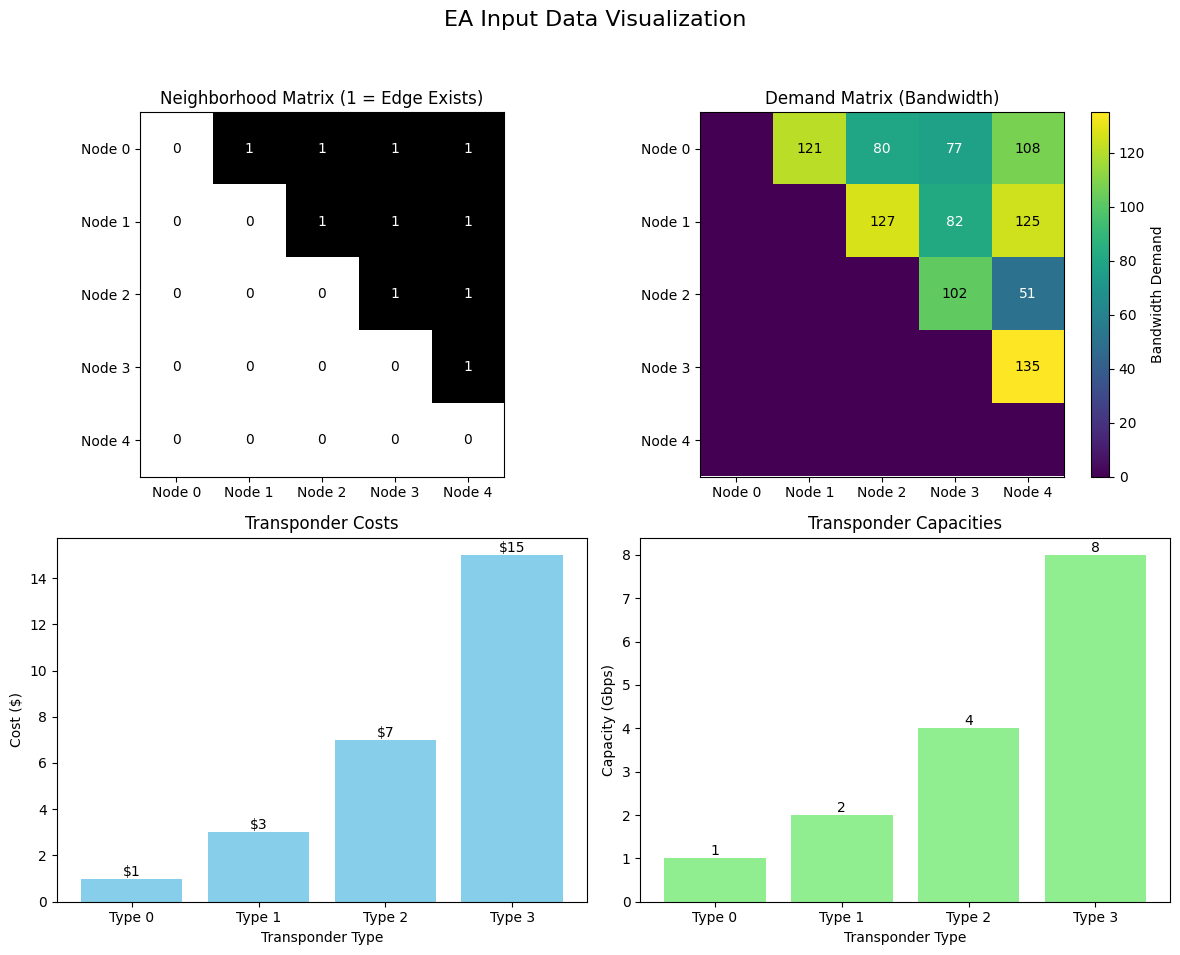

In [90]:
visualize_input_data(
    mock_neigh_matrix,
    mock_demand,
    mock_transponder_costs,
    mock_transponder_capacities
)

## Experiment run

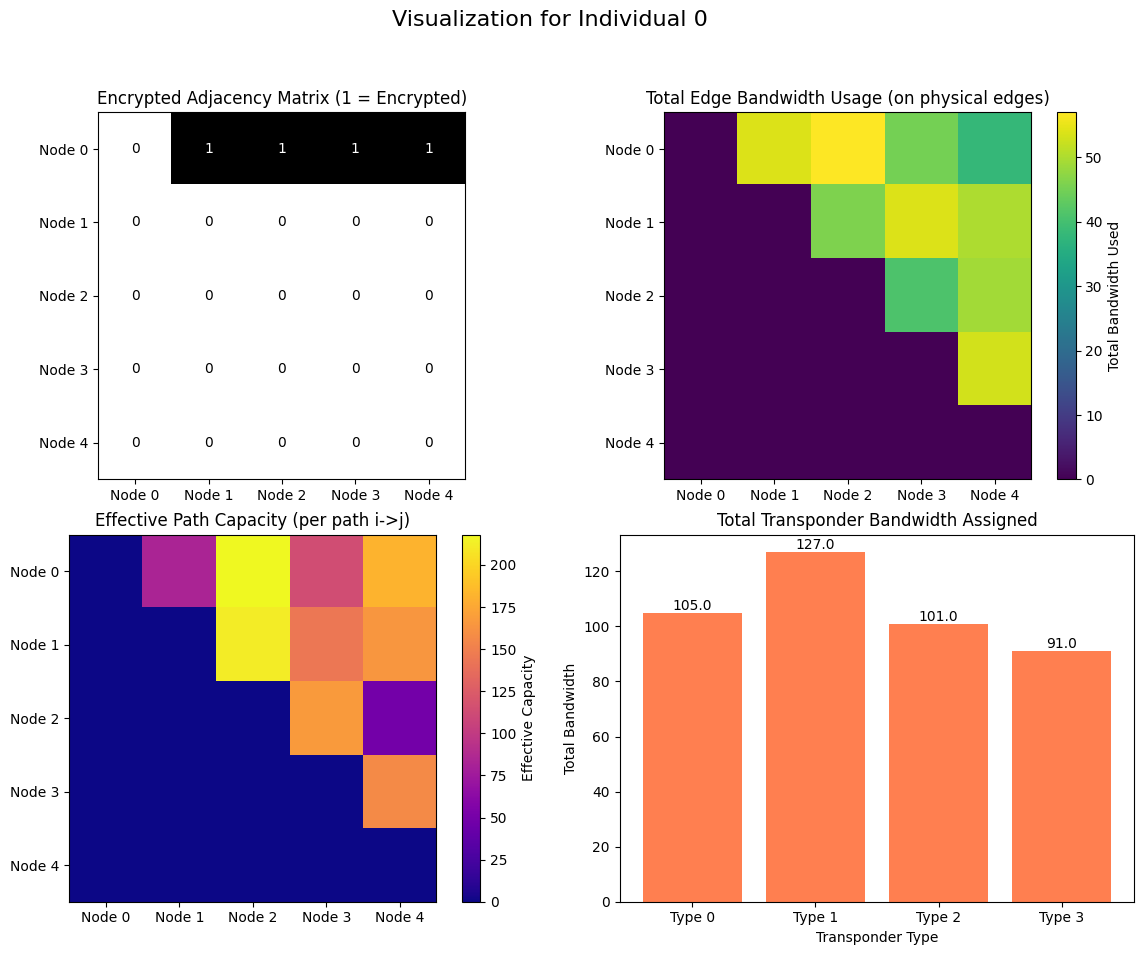

----------------------------------------
it: 1
lowest_penalty: inf
lowest_penalty_constraint_scores:
{   'At Least As Many Paths As Transponders': 1.0,
    'Bandwidth Limit': 1.0,
    'Demand': 1.0,
    'Path Bandwidth IO Match': 1.0,
    'Path Edge Bandwidth Kirchhoff': 1.0}
lowest_transponder_cost: inf
----------------------------------------
it: 1/10
avg_iter_time: 0.0087s
projected_rem: 0.1s
----------------------------------------
it: 2
lowest_penalty: 12211.646484375
lowest_penalty_constraint_scores:
{   'At Least As Many Paths As Transponders': 0.35036107897758484,
    'Bandwidth Limit': 0.0347943976521492,
    'Demand': 0.06265256553888321,
    'Path Bandwidth IO Match': 0.22100000083446503,
    'Path Edge Bandwidth Kirchhoff': 0.25232383608818054}
lowest_transponder_cost: 1929.0
----------------------------------------
it: 2/10
avg_iter_time: 0.0083s
projected_rem: 0.1s
----------------------------------------
it: 3
lowest_penalty: 12211.646484375
lowest_penalty_constraint_sco

In [91]:
ea_instance.run(
    neigh_matrix=mock_neigh_matrix,
    demand=mock_demand,
    transponder_costs=mock_transponder_costs,
    transponder_capacities=mock_transponder_capacities
)

print("\n--- EA Run Finished ---")